## Project Goal

The objective of this project is to **reproduce the results of the IVON paper**  
([Shen et al., 2024](https://proceedings.mlr.press/v235/shen24b.html)).  
IVON presents a refined and elegant synthesis of several influential prior works in adaptive Bayesian optimization and natural gradient methods, including:

- [**Khan et al.**](https://dl.acm.org/doi/abs/10.5555/3648699.3648980)  
- [**Khan & Rue**](https://proceedings.mlr.press/v80/khan18a.html)  
- [**Lin et al.**](https://proceedings.mlr.press/v119/lin20d.html)  
- [**Zhang et al.**](https://dl.acm.org/doi/10.5555/3454287.3454673)

This project aims to carefully reconstruct the experimental setup, methodology, and quantitative findings presented in the paper to ensure a faithful replication.

For deeper context, motivations, and additional explanations, consult:

- https://ysngshn.github.io/research/why-ivon/  
- https://adaptive-bayesian.ai/blog/ivon/
- https://github.com/team-approx-bayes/ivon-experiments


In [ ]:
# Install dependencies
!pip install -r requirements.txt

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt
import pandas as pd
from torch.utils.data import Dataset, DataLoader
import seaborn as sns
import numpy as np
from sklearn.metrics import roc_curve, roc_auc_score, precision_recall_curve, auc
import sys

# Use OmegaConf to define hyperparameter configs
from omegaconf import OmegaConf, DictConfig

# Pretty progress bars
from tqdm import tqdm

# Import evaluation metric and plotting functions from metrics.py
from metrics import evaluate_all_probs, compute_brier, compute_ece, plot_calibration_curve

# Import functionality for loading model checkpoints, initializing optimizers etc
from utils import load_checkpoint, init_model, init_optimizer, load_dataset

In [2]:
device = torch.device('cuda:0') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cuda:0


In [3]:

print("Python version:")
print(sys.version)

print("\nPyTorch version:")
print(torch.__version__)

Python version:
3.12.3 (main, Nov  6 2025, 13:44:16) [GCC 13.3.0]

PyTorch version:
2.9.1+cu128


# CIFAR-10
## Loading, Splitting, and Preparing the CIFAR-10 Dataset

This section loads the CIFAR-10 dataset and applies standard preprocessing used in many deep-learning experiments. CIFAR-10 contains 60,000 color images at 32×32 resolution across 10 classes. For more information, see the official dataset page: [CIFAR-10 Dataset](https://www.cs.toronto.edu/~kriz/cifar.html). We use the standard CIFAR-10 channel-wise mean and standard deviation `(0.4914, 0.4822, 0.4465)` and `(0.2470, 0.2435, 0.2616)` to normalize images, which helps stabilize training by making pixel values more consistent. The dataset is loaded using the `torchvision.datasets.CIFAR10` class documented at: [torchvision CIFAR10](https://docs.pytorch.org/vision/main/generated/torchvision.datasets.CIFAR10.html).

We do a train/validation split with 90% of the development set used for training and 10% for validation. The test set is held out and used only for final evaluation of key quantities. We apply data augmentation in the form of random cropping and random horizontal flips, in accordiance with what is done in the [IVON reference implementation](https://github.com/team-approx-bayes/ivon-experiments/blob/main/common/dataloaders.py).

The data loading functionality is implemented in [utils.py](./utils.py)

In [4]:
train_set, val_set, test_set = load_dataset(name="cifar10", train_ratio=0.9, root="data", seed=42)

# --- DataLoaders (batch_size = 50 to match IVON paper) ---
train_loader = torch.utils.data.DataLoader(train_set, batch_size=50, shuffle=True)
val_loader   = torch.utils.data.DataLoader(val_set,   batch_size=50, shuffle=False)
test_loader  = torch.utils.data.DataLoader(test_set,  batch_size=50, shuffle=False)


## ResNet-20 Implementation

The following code block implements **ResNet-20 exactly as described in the original paper**  
[**Deep Residual Learning for Image Recognition**](https://ieeexplore.ieee.org/stamp/stamp.jsp?arnumber=7780459)

Important clarifications:

- The **original authors did not release their CIFAR-ResNet20 implementation in PyTorch**  
  (their official codebase was in [**Caffe**](https://github.com/KaimingHe/deep-residual-networks)).
- The **IVON paper** uses “the standard CIFAR-10 20-layer ResNet” from the original work,  
  but does **not** include its own ResNet20 implementation in the repository.
- Therefore, our implementation follows the **canonical and widely-used PyTorch version**:  
  https://github.com/kuangliu/pytorch-cifar/blob/master/models/resnet.py  
  which is a faithful reproduction of the architecture in the main ResNet paper.

This ensures that our model architecture is **fully aligned** with both the **original ResNet-20 design** and the **model used in IVON experiments**.

The code for ResNet-20 is in [resnet20.py](./resnet20.py).

# Unified Evaluation & Calibration Metrics

This section provides helper functions for evaluating classification models trained with both **deterministic optimizers** (SGD, AdamW) and **posterior‐sampling optimizers** such as **IVON**.  
The evaluation includes both **accuracy metrics** and **uncertainty metrics**, providing a complete understanding of model behavior.

---

## 1. `evaluate_probs()` — Probability Extraction & Posterior Sampling

This function computes model probabilities under different inference regimes:

### **A. Deterministic Models (SGD, AdamW)**  
Uses fixed model parameters:

$$
p_i = \operatorname{softmax}(f_\theta(x_i))
$$

### **B. IVON@mean (`test_samples = 0`)**  
Uses the **posterior mean** \( m \) as the model parameters:

$$
\theta = m
$$

### **C. IVON Posterior Sampling (`test_samples ≥ 1`)**

- `test_samples = 1` → one posterior sample  
- `test_samples > 1` → Monte Carlo posterior averaging:

$$
\bar{p}_i =
\frac{1}{T}
\sum_{t=1}^{T}
\operatorname{softmax}(f_{\theta^{(t)}}(x_i))
$$

The function returns:
- Predicted probabilities  
- Ground‐truth labels  
- Logits (needed for NLL)

---

## 2. `plot_calibration_curve()` — Reliability Diagram

A reliability diagram visualizes how predicted confidence aligns with empirical accuracy.

For each sample \( i \):

- Confidence:
  $$
  c_i = \max_k p_{ik}
  $$

- Predicted class:
  $$
  \hat{y}_i = \arg\max_k p_{ik}
  $$

- Correctness:
  $$
  \text{correct}_i =
  \begin{cases}
  1, & \hat{y}_i = y_i \\
  0, & \text{otherwise}
  \end{cases}
  $$

Samples are binned by confidence, and for each bin \( B_m \):

$$
\text{acc}(B_m)
=
\frac{1}{|B_m|}
\sum_{i \in B_m}
\mathbf{1}[\hat{y}_i = y_i]
$$

$$
\text{conf}(B_m)
=
\frac{1}{|B_m|}
\sum_{i \in B_m}
c_i
$$

A perfectly calibrated model lies on the diagonal \( y = x \).

---

## 3. `compute_ece()` — Expected Calibration Error (ECE)

ECE quantifies the misalignment between confidence and accuracy:

$$
\text{ECE}
=
\sum_{m=1}^{M}
\frac{|B_m|}{N}
\,
\left|
\text{acc}(B_m)
-
\text{conf}(B_m)
\right|
$$

Lower ECE means better calibration.

---

## 4. `evaluate_all_metrics()` — Comprehensive Evaluation

This function computes both accuracy and uncertainty metrics.

### **Top-1 Accuracy**
$$
\text{Acc@1}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}[\hat{y}_i = y_i]
$$

### **Top-5 Accuracy**
$$
\text{Acc@5}
=
\frac{1}{N}
\sum_{i=1}^{N}
\mathbf{1}[y_i \in \text{Top5}(p_i)]
$$

### **Negative Log-Likelihood (NLL)**
$$
\text{NLL}
=
-\frac{1}{N}
\sum_{i=1}^{N}
\log p_{i, y_i}
$$

### **Expected Calibration Error (ECE)**  
(as defined above)

### **Brier Score**
$$
\text{Brier}
=
\frac{1}{N}
\sum_{i=1}^{N}
\sum_{k=1}^{K}
\left(p_{ik} - \mathbf{1}[y_i = k]\right)^2
$$

The function returns all metrics plus raw probabilities and labels.

---

## 5. `compare_methods()` — Evaluate Multiple Training Methods

This utility evaluates several optimizers under a shared protocol.

### **Input format**
```python
methods_dict = {
    "SGD":       (model_sgd, optimizer_sgd, 0),
    "AdamW":     (model_adam, optimizer_adam, 0),
    "IVON@mean": (model_ivon, optimizer_ivon, 0),
    "IVON-MC8":  (model_ivon, optimizer_ivon, 8)
}


In [5]:

def evaluate_all_metrics(model: nn.Module, 
                         optimizer: torch.optim.Optimizer, 
                         loader: DataLoader, 
                         device: torch.device, 
                         test_samples=0) -> dict[str, torch.Tensor | float]:
    """
    Runs through all the methods and assembles the sub-results into a dictionary.
    """
    model.eval()

    probs, labels, logits = evaluate_all_probs(
        model, optimizer, loader, device, test_samples
    )

    # Top-1 accuracy
    top1 = (probs.argmax(1) == labels).float().mean().item()

    # Top-5 accuracy (safe for CIFAR-10 & larger datasets)
    top5 = (
        probs.topk(min(5, probs.size(1)), dim=1).indices
        .eq(labels.unsqueeze(1))
        .any(dim=1)
        .float()
        .mean()
        .item()
    )

    # True NLL (cross-entropy)
    nll = F.cross_entropy(logits, labels, reduction="mean").item()

    # ECE
    ece = compute_ece(probs, labels)

    # Brier score
    brier = compute_brier(probs, labels)

    return {
        "Top-1 Acc ↑": top1,
        "Top-5 Acc ↑": top5,
        "NLL ↓": nll,
        "ECE ↓": ece,
        "Brier ↓": brier,
        "probs": probs,
        "labels": labels,
    }
    
#=========================================================================

def compare_methods(methods_dict: dict[str, tuple[nn.Module, torch.optim.Optimizer, int]], 
                    loader: DataLoader, 
                    device: torch.device) -> pd.DataFrame:
    """
    Runs through all experiment configs in 'methods_dict' and assembles a pandas DataFrame with the results in a table

    Example of a valid methods_dict:
    {
        "IVON@mean": (model_ivon, optimizer_ivon, 0),
        "IVON-MC8":  (model_ivon, optimizer_ivon, 8),
        "SGD":       (model_sgd, optimizer_sgd, 0)
    }
    """

    rows = []

    for name, (model, optimizer, samples) in methods_dict.items():
        print(f"Evaluating {name} (samples={samples})...")

        metrics = evaluate_all_metrics(
            model=model,
            optimizer=optimizer,
            loader=loader,
            device=device,
            test_samples=samples
        )

        rows.append({
            "Method": name,
            "Top-1 Acc ↑": metrics["Top-1 Acc ↑"],
            "Top-5 Acc ↑": metrics["Top-5 Acc ↑"],
            "NLL ↓": metrics["NLL ↓"],
            "ECE ↓": metrics["ECE ↓"],
            "Brier ↓": metrics["Brier ↓"],
        })

    df = pd.DataFrame(rows).set_index("Method")
    print("\n=== Comparison Table ===")
    print(df)
    return df


## Performance comparison on CIFAR-10

In [6]:
# Load checkpoints trained for CIFAR-10 (consult Training.ipynb for how this was done)

# IVON
ivon_model, ivon_optim, ivon_config = load_checkpoint("ivon", dataset_name="cifar10", model_name="resnet20",
                                                      epoch=200, device=device)

# AdamW; Note that we load an early stopping version as well, as heavy overfitting was observed while training.
adamw_model, adamw_optim, adamw_config = load_checkpoint("adamw", dataset_name="cifar10", model_name="resnet20", 
                                                         epoch=200, device=device)
adamw_early_model, adamw_early_optim, adamw_early_config = load_checkpoint("adamw", dataset_name="cifar10", model_name="resnet20",
                                                                           epoch=25, device=device)

# SGD
sgd_model, sgd_optim, sgd_config = load_checkpoint("sgd", dataset_name="cifar10", model_name="resnet20", epoch=200, device=device)


Loaded config: {'lr': 0.2, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'lambda_': 45000, 'h0': 0.5, 'beta1': 0.9, 'beta2': 0.99999, 'weight_decay': 0.0002}, 'n_classes': 10}
Loaded config: {'lr': 0.002, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'beta1': 0.9, 'beta2': 0.999, 'weight_decay': 0.0002}, 'n_classes': 10}
Loaded config: {'lr': 0.002, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'beta1': 0.9, 'beta2': 0.999, 'weight_decay': 0.0002}, 'n_classes': 10}
Loaded config: {'lr': 0.1, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'beta1': 0.9, 'weight_decay': 0.0002}, 'n_classes': 10}


In [7]:
# Compare the performance metrics on all models
experiment_dict = {
    "IVON@mean": (ivon_model, ivon_optim, 0),
    "IVON-MC8": (ivon_model, ivon_optim, 8),
    "AdamW": (adamw_model, adamw_optim, 0),
    "AdamW-e25": (adamw_early_model, adamw_early_optim, 0),
    "SGD": (sgd_model, sgd_optim, 0)
}
data = compare_methods(experiment_dict, loader=test_loader, device=device)
data.head()

Evaluating IVON@mean (samples=0)...
Evaluating IVON-MC8 (samples=8)...
Evaluating AdamW (samples=0)...
Evaluating AdamW-e25 (samples=0)...
Evaluating SGD (samples=0)...

=== Comparison Table ===
           Top-1 Acc ↑  Top-5 Acc ↑     NLL ↓     ECE ↓   Brier ↓
Method                                                           
IVON@mean       0.8982       0.9938  0.367811  0.044689  0.015535
IVON-MC8        0.8920       0.9939  0.337697  0.027437  0.015907
AdamW           0.8810       0.9945  0.670467  0.082548  0.019972
AdamW-e25       0.8552       0.9941  0.439225  0.034369  0.021067
SGD             0.8978       0.9942  0.362516  0.043634  0.015476


,Top-1 Acc ↑,Top-5 Acc ↑,NLL ↓,ECE ↓,Brier ↓
Method,,,,,
IVON@mean,0.8982,0.9938,0.367811,0.044689,0.015535
IVON-MC8,0.8920,0.9939,0.337697,0.027437,0.015907
AdamW,0.8810,0.9945,0.670467,0.082548,0.019972
AdamW-e25,0.8552,0.9941,0.439225,0.034369,0.021067
SGD,0.8978,0.9942,0.362516,0.043634,0.015476


Plotting calibration curve for IVON@mean ...
Plotting calibration curve for IVON-MC8 ...
Plotting calibration curve for AdamW ...
Plotting calibration curve for AdamW-e25 ...
Plotting calibration curve for SGD ...


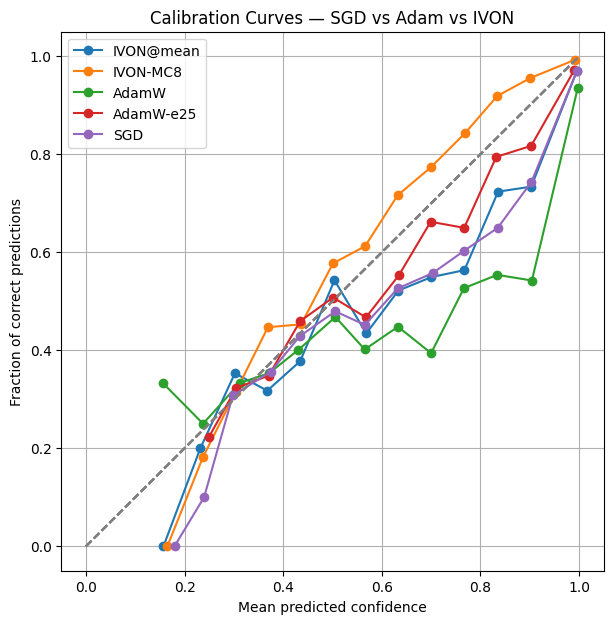

In [8]:
# Plot calibration curve

plt.figure(figsize=(7,7))

for name, (model_m, optim_m, test_samples) in experiment_dict.items():
    print(f"Plotting calibration curve for {name} ...")
    probs, labels, _ = evaluate_all_probs(model_m, optim_m, test_loader, device, test_samples)
    plot_calibration_curve(probs, labels, n_bins=15, label_name=name)

plt.title("Calibration Curves — SGD vs Adam vs IVON")
plt.legend()
plt.grid(True)
plt.show()


Here we generate the plots for 2c


Evaluating IVON with 1 test samples...
  NLL = 0.5543   Acc = 0.8465

Evaluating IVON with 2 test samples...
  NLL = 0.4209   Acc = 0.8749

Evaluating IVON with 4 test samples...
  NLL = 0.3700   Acc = 0.8832

Evaluating IVON with 8 test samples...
  NLL = 0.3372   Acc = 0.8965

Evaluating IVON with 16 test samples...
  NLL = 0.3243   Acc = 0.8969

Evaluating IVON with 32 test samples...
  NLL = 0.3217   Acc = 0.8974

Evaluating IVON with 64 test samples...
  NLL = 0.3189   Acc = 0.9012


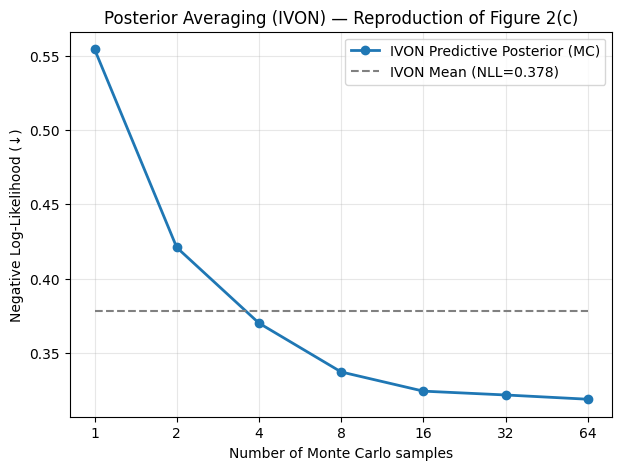

In [9]:
from statistics import mean

mc_samples_list = [1, 2, 4, 8, 16, 32, 64]
ivon_nlls = []
ivon_accs = []

for S in mc_samples_list:
    print(f"\nEvaluating IVON with {S} test samples...")

    metrics = evaluate_all_metrics(
        model=ivon_model,
        optimizer=ivon_optim,
        loader=test_loader,
        device=device,
        test_samples=S,
    )

    ivon_nlls.append(metrics["NLL ↓"])
    ivon_accs.append(metrics["Top-1 Acc ↑"])

    print(f"  NLL = {metrics['NLL ↓']:.4f}   Acc = {metrics['Top-1 Acc ↑']:.4f}")


plt.figure(figsize=(7,5))

# Posterior predictive curve
plt.plot(mc_samples_list, ivon_nlls, marker="o", linewidth=2,
         label="IVON Predictive Posterior (MC)")

# Mean baseline (dashed)
plt.hlines(mean(ivon_nlls), mc_samples_list[0], mc_samples_list[-1],
           colors="gray", linestyles="--",
           label=f"IVON Mean (NLL={mean(ivon_nlls):.3f})")

plt.xscale("log", base=2)
plt.xticks(mc_samples_list, mc_samples_list)

plt.xlabel("Number of Monte Carlo samples")
plt.ylabel("Negative Log-Likelihood (↓)")
plt.title("Posterior Averaging (IVON) — Reproduction of Figure 2(c)")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

Validation perplexity

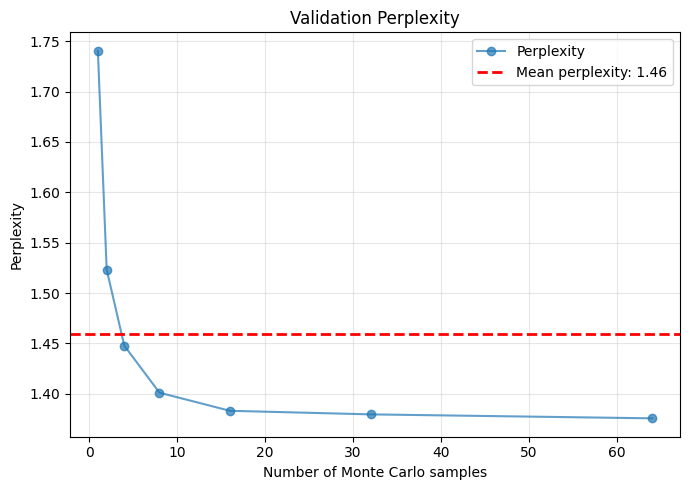

In [10]:
# Validation perplexity
ivon_perplexities = [np.exp(nll) for nll in ivon_nlls]
mean_perplexity = np.exp(mean(ivon_nlls))

plt.figure(figsize=(7,5))

# Plot individual perplexities
# Plot: x = mc_samples_list, y = perplexities
plt.plot(mc_samples_list, ivon_perplexities, marker='o', linestyle='-', alpha=0.7,
         label='Perplexity')

# Add mean perplexity as a horizontal line
plt.axhline(y=mean_perplexity, color='r', linestyle='--', linewidth=2, label=f'Mean perplexity: {mean_perplexity:.2f}')

# Labels and formatting
plt.xlabel('Number of Monte Carlo samples')
plt.ylabel('Perplexity')
plt.title('Validation Perplexity')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()

plt.show()

## Understanding `train_samples` and `test_samples` in IVON

Having understood the implementation details in the previous cells of the notebook, we now turn to clarify the conceptual distinction between the two sampling parameters, **`train_samples`** and **`test_samples`**, which appear in the code. Both originate from the same variational Bayesian principle but play distinct roles in the learning and inference stages. During training, the optimizer minimizes

$$
{L}(q) = \lambda\, \mathbb{E}_{q_{\eta}(\theta)}[\bar{\ell}(\theta)] + D_{\mathrm{KL}}(q_{\eta}(\theta)\,\|\,p(\theta)),
$$  

where $q_{\eta}(\theta)$ is the approximate posterior over network weights. Because the expectation over $q_{\eta}(\theta)$ is intractable, it is replaced by a Monte Carlo estimate obtained through a finite number of **train-time samples**:  

$$
\nabla_{\eta}{L}(q) \approx \frac{1}{S_{\text{train}}} \sum_{s=1}^{S_{\text{train}}} \nabla_{\eta}\ell(\theta^{(s)}),
\quad \theta^{(s)} \sim q_{\eta}(\theta).
$$  

Each sampled parameter vector $\theta^{(s)}$ represents a stochastic realization of the model’s weights used to compute the loss gradient, thereby injecting uncertainty directly into the optimization process. The parameter `train_samples` thus determines how many such draws are taken per minibatch, balancing computational cost against the variance of the gradient estimate.

At evaluation time, the same variational posterior $q_{\eta}(\theta)$ is employed to form predictions that integrate over parameter uncertainty. Since the predictive distribution  

$$
p(y \mid x) = \int p(y \mid x, \theta)\, q_{\eta}(\theta)\, d\theta
$$  

is also analytically intractable, it is approximated via Monte Carlo averaging over **test-time samples**:  

$$
p(y \mid x) \approx \frac{1}{S_{\text{test}}} \sum_{s=1}^{S_{\text{test}}} p(y \mid x, \theta^{(s)}),
\quad \theta^{(s)} \sim q_{\eta}(\theta).
$$  

Here, `test_samples` specifies the number of posterior weight realizations used to average predictions, determining the accuracy of the Bayesian model average approximation. Increasing `test_samples` improves calibration and negative log-likelihood but incurs greater inference cost. As demonstrated in the subsequent code reproducing **Figure 4** of the original paper, varying these two sampling parameters—during both training and testing—reveals their complementary influence on model accuracy and uncertainty, illustrating how IVON leverages stochasticity across both phases to achieve well-calibrated predictive performance.


In [11]:
# ==============================================================
# Reproduce Figure 4 from the IVON paper:
# Effect of Monte Carlo samples during inference
# and training on Accuracy and NLL.
# ==============================================================

# --------------------------------------------------------------
# Evaluate Accuracy and NLL for different test_samples values
# --------------------------------------------------------------
def evaluate_metric_sweep(model, optimizer, test_loader, test_samples_list):
    accs, nlls = [], []

    ivon_mode = hasattr(optimizer, "sampled_params")

    for t in test_samples_list:

        # --- IMPORTANT ---
        # Only IVON supports test_samples > 0
        # SGD / AdamW MUST always use test_samples = 0
        if not ivon_mode:
            t = 0  # force deterministic behavior

        metrics = evaluate_all_metrics(model, optimizer, test_loader, device, test_samples=t)
        accs.append(metrics["Top-1 Acc ↑"])
        nlls.append(metrics["NLL ↓"])

    return accs, nlls


In [12]:
# # --------------------------------------------------------------
# # 3. Figure 4 — Top row: Varying test_samples
# # --------------------------------------------------------------

test_samples_list = [1, 2, 4, 8, 16, 32]
accs_test, nlls_test = evaluate_metric_sweep(ivon_model, ivon_optim, test_loader, test_samples_list)

df_test = pd.DataFrame({
    "Test Samples (MC)": test_samples_list,
    "Accuracy": accs_test,
    "NLL": nlls_test,
})
display(df_test)


,Test Samples (MC),Accuracy,NLL
0,1,0.8434,0.562426
1,2,0.8734,0.426420
2,4,0.8857,0.369410
3,8,0.8929,0.338859
4,16,0.8972,0.328018
5,32,0.8998,0.320155


In [13]:
# ============================================================
# Helper for consistent plotting style
# ============================================================
def plot_panel(ax, x, y, title, xlabel, ylabel, color=None):
    ax.plot(x, y, marker="o", color=color)
    ax.set_title(title, fontsize=12)
    ax.set_xlabel(xlabel)
    ax.set_ylabel(ylabel)
    ax.grid(True)




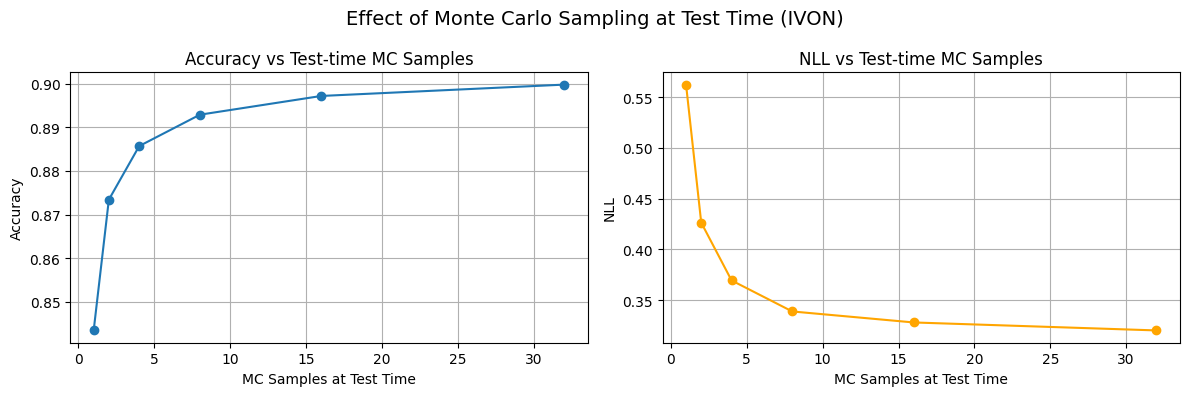

In [14]:
# ============================================================
# Figure 1 — Test-time MC sweep
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

plot_panel(
    axes[0], test_samples_list, accs_test,
    "Accuracy vs Test-time MC Samples",
    "MC Samples at Test Time",
    "Accuracy"
)

plot_panel(
    axes[1], test_samples_list, nlls_test,
    "NLL vs Test-time MC Samples",
    "MC Samples at Test Time",
    "NLL",
    color="orange"
)

plt.suptitle("Effect of Monte Carlo Sampling at Test Time (IVON)", fontsize=14)
plt.tight_layout()
plt.show()




In [19]:
# Showcase impact of the number of training MC samples

accs_train = []
nlls_train = []
train_samples_list = [1, 2]

for s in train_samples_list:

    # Load a checkpoint trained with relevant number of samples
    model_s, opt_s, config = load_checkpoint("ivon", dataset_name="cifar10", model_name="resnet20",
                                             epoch=200, n_samples=(s if s > 1 else None), device=device)

    # Evaluate using posterior mean
    metrics = evaluate_all_metrics(
        model_s,
        opt_s,
        test_loader,
        device,
        test_samples=0
    )

    accs_train.append(metrics["Top-1 Acc ↑"])
    nlls_train.append(metrics["NLL ↓"])

    print(f"train_samples={s} → Acc={accs_train[-1]:.4f}, NLL={nlls_train[-1]:.4f}")

# 4. Build final DataFrame
df_train = pd.DataFrame({
    "Train Samples (MC)": train_samples_list,
    "Accuracy": accs_train,
    "NLL": nlls_train,
})

display(df_train)

Loaded config: {'lr': 0.2, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'lambda_': 45000, 'h0': 0.5, 'beta1': 0.9, 'beta2': 0.99999, 'weight_decay': 0.0002}, 'n_classes': 10}
train_samples=1 → Acc=0.8982, NLL=0.3678
Loaded config: {'lr': 0.2, 'batch': 50, 'epochs': 200, 'warmup_epochs': 5, 'optim': {'n_samples': 2, 'lambda_': 45000, 'h0': 0.5, 'beta1': 0.9, 'beta2': 0.99999, 'weight_decay': 0.0002}, 'n_classes': 10}
train_samples=2 → Acc=0.9223, NLL=0.2882


,Train Samples (MC),Accuracy,NLL
0,1,0.8982,0.367811
1,2,0.9223,0.288175
